# Applying supervised learning to predict student dropout





In [ ]:
#pip install -q -U keras-tuner
!pip install --upgrade tensorflow keras-tuner xgboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 32.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.15.1
    Uninstalling h5py-3.15.1:
      Successfully uninstalled h5py-3.15.1
  Attempting uninstall: shap
    Found existing installation: shap 0.50.0
    Uninstalling shap-0.50.0:
      Successfully uninstalled shap-0.50.0
  Attempting uninstall: keras
    Found existing installation: keras 

In [ ]:
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 19.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
import tensorflow as tf
import plotly as pt
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import xgboost as xgb
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, precision_recall_curve, average_precision_score)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from IPython.display import Image, display
from plotly.subplots import make_subplots

from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.optimizers import Adam, RMSprop
import keras.backend as K
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from functools import partial

In [ ]:
seed = 12

In [ ]:
#To save plotly graphs so that they are visible when code is downloaded
pio.renderers.default = "colab"

# Stage 1 Pre-processing

In [ ]:
file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"

**Stage 1: Pre-processing**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

In [ ]:
#Load data
data1 = pd.read_csv(file_url)

data1.shape

(25059, 16)

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
9495,ISC_Lancaster,2471548,Agent,Standard Agent Booking,NaN,19/03/2001,Male,Chinese,ShanDong Province,Weifang City,Foundation,Business and Management Studies Foundation Year,False,Yes,BSc Finance,Lancaster University
20481,ISC_Sheffield,2763856,Agent,Standard Agent Booking,NaN,27/03/2004,Female,Chinese,NaN,Changshu; Jiangsu,Foundation,International Foundation Year Business; Social...,False,Yes,BA (Hons) Business Management and Economics,University of Sheffield International College
24751,ISC_Teesside,2666688,Agent,Standard Agent Booking,NaN,21/08/2003,Female,Indian,Haryana,KURUKSHETRa,International Year One,International Year One: Business (ICAS),True,No,BA (Hons) International Business,Teesside University


In [ ]:
data1.columns

Index(['CentreName', 'LearnerCode', 'BookingType', 'LeadSource',
       'DiscountType', 'DateofBirth', 'Gender', 'Nationality', 'HomeState',
       'HomeCity', 'CourseLevel', 'CourseName', 'IsFirstIntake',
       'CompletedCourse', 'ProgressionDegree', 'ProgressionUniversity'],
      dtype='object')

In [ ]:
data1 = data1.drop(columns = ['LearnerCode'])

In [ ]:
#Reusable function to remove columns with categorical data of high cardinality
def remove_high_cardinality(benchmark, data, cat_columns):

  for column in cat_columns:
    # Check if the number of unique values in the column is greater than the benchmark
    if data[column].nunique() > benchmark:
      data = data.drop(columns = [column])
      print(f"Dropped: '{column}'")
      cat_columns.remove(column)

  return data, cat_columns

In [ ]:
cat_columns1 = ['CentreName', 'BookingType', 'LeadSource', 'DiscountType','Gender', 'Nationality', 'HomeState','HomeCity', 'CourseLevel', 'CourseName', 'ProgressionDegree', 'ProgressionUniversity']

data1, cat_columns1 = remove_high_cardinality(benchmark = 200, data = data1, cat_columns = cat_columns1)

Dropped: 'HomeState'
Dropped: 'ProgressionDegree'


In [ ]:
#Reusable function to remove features with high levels of missing data
def remove_high_NA(benchmark, data, cat_columns):

  for column in data.columns:
    if (data[column].isna().sum() / data.shape[0]) > benchmark:
      data = data.drop(columns = [column])
      print(f"Dropped: '{column}'")
      if column in cat_columns:
        cat_columns.remove(column)

  return data, cat_columns

In [ ]:
#Remove features with high levels of missing data
data1, cat_columns1 = remove_high_NA(benchmark = 0.5, data = data1, cat_columns = cat_columns1)

Dropped: 'DiscountType'


In [ ]:
#Identify any other missing data
missing_counts = data1.isnull().sum()
features_missing = missing_counts[missing_counts > 0]

missing_summary = pd.DataFrame({
    'missing_count': features_missing,
    'missing_pct': features_missing / len(data1) * 100
})

missing_summary

,missing_count,missing_pct
HomeCity,3448,13.759528


In [ ]:
def impute_home_city(data):
  # Calculate the mode for each nationality
  mode_by_nationality = data.groupby('Nationality')['HomeCity'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else "Unknown"
)

  # Fill the missing values in the original HomeCity column
  data['HomeCity'] = data['HomeCity'].fillna(mode_by_nationality)

  return data

In [ ]:
#Impute home city
data1 = impute_home_city(data1)

In [ ]:
#Examine CourseLevel data
data1['CourseLevel'].value_counts()

,count
CourseLevel,
Foundation,14666
Pre-Masters,5905
International Year One,4441
International Year Two,47


In [ ]:
#Ordinaly encode CourseLevel data
course_order = ['Foundation', 'Pre-Masters', 'International Year One', 'International Year Two']
ordinal_encoder = OrdinalEncoder(categories=[course_order])

data1['CourseLevel'] = ordinal_encoder.fit_transform(data1[['CourseLevel']]).astype(int)

if 'CourseLevel' in cat_columns1:
    cat_columns1.remove('CourseLevel')

In [ ]:
#One hot code other categorical data
data1 = pd.get_dummies(data1, columns=cat_columns1, drop_first=False, dtype=int)

In [ ]:
#Examine df again
data1.sample(10)

,DateofBirth,CourseLevel,IsFirstIntake,CompletedCourse,CentreName_ISC_Aberdeen,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
13876,18/12/1999,0,False,Yes,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10850,5/7/1997,0,False,Yes,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
24279,12/1/2002,2,False,Yes,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3205,2/4/2001,0,False,Yes,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
22754,16/05/2001,2,False,Yes,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
881,27/02/2003,0,False,Yes,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10957,29/03/2001,0,False,Yes,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
11110,2/2/2000,0,False,No,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9685,12/7/2003,0,False,Yes,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23124,14/08/2000,2,False,Yes,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
#Convert date of birth to age
data1['Age'] = (pd.to_datetime('today') - pd.to_datetime(data1['DateofBirth'], dayfirst=True)).dt.days // 365
data1 = data1.drop(columns = ['DateofBirth'])

In [ ]:
#Convert target variable - CompletedCourse - to a binary value, and student dropped out as the target
data1['CompletedCourse'] = np.where(data1['CompletedCourse'].str.lower() == 'yes', 0, 1)

In [ ]:
#Convert 'IsFirstIntake' from Boolean to binary
data1['IsFirstIntake'] = np.where(data1['IsFirstIntake'] == 'yes', 1, 0)

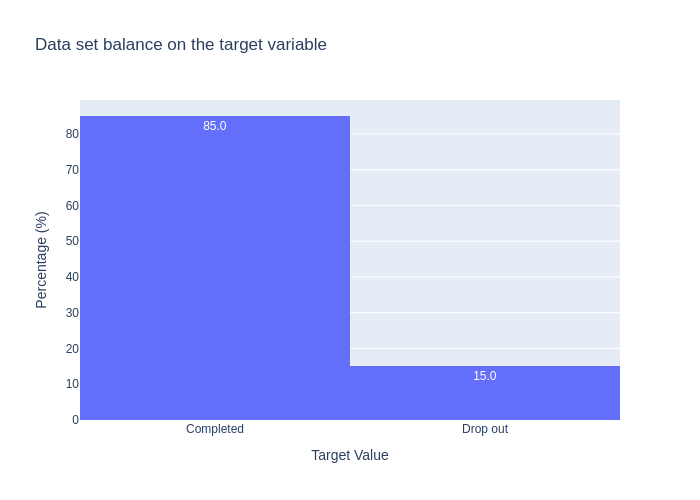

In [ ]:
#Examine balance in Completed Course
fig = px.histogram(data1['CompletedCourse'],
                   x = data1['CompletedCourse'].values,
                   category_orders = {'x': [0,1]},
                   histnorm='percent',
                   text_auto='.1f',
                   title = 'Data set balance on the target variable')

fig.update_layout(xaxis_title = 'Target Value',
                  yaxis_title = 'Percentage (%)',
                  xaxis = dict(tickmode = 'array', tickvals = [0,1], ticktext = ['Completed', 'Drop out']) #This tell plotly, only use the values I specify
                  )

fig.write_image("completed_course_balance.png")
display(Image("completed_course_balance.png"))

Class imbalance needs to be addressed, as a model that trivially predicts course completing all the time would have an accuracy rate of 85%. As a result, optimise for 'PR AUC' & use stratification when creating the train, val and test sets.

# Reusable model functions

Functions for Performance Evaluation

In [ ]:
#Reusuable function for model evaluation and storing of results
def evaluate_model(X_test, y_test, threshold=0.5, model=None):
    if hasattr(model, 'predict_proba'): # If the model has a predict_proba method, i.e XGBoost
        soft_probs = model.predict_proba(X_test)[:, 1]
    else: # Keras
        soft_probs = model.predict(X_test).flatten()

    hard_pred = (soft_probs > threshold).astype("int32")

    cm = confusion_matrix(y_test, hard_pred)

    model_name = type(model).__name__

    # Set a better name
    if model_name == "Sequential":
        model_name = "Keras_Neural_Net"

    new_entry = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, hard_pred),
        'Precision': precision_score(y_test, hard_pred),
        'Recall': recall_score(y_test, hard_pred),
        'F1 Score': f1_score(y_test, hard_pred),
        'PR AUC': average_precision_score(y_test, soft_probs)
    }

    #Get coordinates for the PR Curve
    precisions, recalls, _ = precision_recall_curve(y_test, soft_probs)

    return cm, new_entry, (precisions, recalls)

In [ ]:
#Reusable function to compare the performance of two models
def compare_performance(baseline_results, delta_results):
  df_b = baseline_results.set_index('Model')
  df_a = delta_results.set_index('Model')

  comparison_df = df_b.join(df_a, lsuffix='_Before', rsuffix='_After')

  comparison_df['Accuracy_Lift'] = comparison_df['Accuracy_After'] - comparison_df['Accuracy_Before']
  comparison_df['Precision_Lift'] = comparison_df['Precision_After'] - comparison_df['Precision_Before']
  comparison_df['Recall_Lift'] = comparison_df['Recall_After'] - comparison_df['Recall_Before']
  comparison_df['F1_Lift'] = comparison_df['F1 Score_After'] - comparison_df['F1 Score_Before']
  comparison_df['PR AUC_Lift'] = comparison_df['PR AUC_After'] - comparison_df['PR AUC_Before']

  ordered_cols = [
     'Accuracy_Before', 'Accuracy_After', 'Accuracy_Lift',
      'Precision_Before', 'Precision_After', 'Precision_Lift',
      'Recall_Before', 'Recall_After', 'Recall_Lift',
      'F1 Score_Before', 'F1 Score_After', 'F1_Lift',
      'PR AUC_Before', 'PR AUC_After', 'PR AUC_Lift'
  ]

  display(comparison_df[ordered_cols])

In [ ]:
#Reusable function to plot precision-accuracy pr auc score and loss curves during training
def plot_training_history(history, epochs):
  baseline_training_training_pr_auc = history.history['pr_auc']
  baseline_training_val_pr_auc = history.history['val_pr_auc']

  baseline_training_training_loss = history.history['loss']
  baseline_training_val_loss = history.history['val_loss']

  plt.figure(figsize=(12, 6))
  x = range(1, epochs+1)

  #Plot the PR AUCs
  plt.plot(x, baseline_training_training_pr_auc, label='Training PR AUC', linestyle='-')
  plt.plot(x, baseline_training_val_pr_auc, label='Validation PR AUC', linestyle='--')

  plt.title('PR AUC curve')
  plt.xlabel('Epochs')
  plt.ylabel('PR AUC')
  plt.legend()
  plt.grid(True)
  plt.show()

  #Plot the losses
  plt.plot(x, baseline_training_training_loss, label='Training Loss', linestyle='-')
  plt.plot(x, baseline_training_val_loss, label='Validation Loss', linestyle='--')

  plt.title('Loss curve')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  return plt

In [ ]:
#Reusable function to compare two Confusion Matrixes
def compare_cms(cm_left, cm_right, name_left="Baseline", name_right="Tuned",
                title="Model Performance: Recall Comparison (%)"):

    def normalize(cm):
        return np.round((cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100, 1)

    cm_l_perc = normalize(cm_left)
    cm_r_perc = normalize(cm_right)

    labels = ['Completed', 'Dropped out']

    trace1 = go.Heatmap(
        z=cm_l_perc,
        x=labels,
        y=labels,
        colorscale="Blues",
        showscale=False
    )

    trace2 = go.Heatmap(
        z=cm_r_perc,
        x=labels,
        y=labels,
        colorscale="Greens",
        showscale=False
    )

    fig = make_subplots(
        rows=1,
        cols=2,
        horizontal_spacing=0.20,
        subplot_titles=(
            f"<b>{name_left} (Recall: {cm_l_perc[1,1]}%)</b>",
            f"<b>{name_right} (Recall: {cm_r_perc[1,1]}%)</b>"
        )
    )

    fig.add_trace(trace1, row=1, col=1)
    fig.add_trace(trace2, row=1, col=2)

    new_annotations = []

    # LEFT confusion matrix (uses x,y not x1,y1)
    for i, row in enumerate(cm_l_perc):
        for j, val in enumerate(row):

            font_color = "white" if val > 50 else "black"

            new_annotations.append(dict(
                x=labels[j],
                y=labels[i],
                text=f"<b>{val}%</b>",
                xref="x",
                yref="y",
                showarrow=False,
                xanchor="center",
                yanchor="middle",
                font=dict(size=22, color=font_color)
            ))

    # RIGHT confusion matrix
    for i, row in enumerate(cm_r_perc):
        for j, val in enumerate(row):

            font_color = "white" if val > 50 else "black"

            new_annotations.append(dict(
                x=labels[j],
                y=labels[i],
                text=f"<b>{val}%</b>",
                xref="x2",
                yref="y2",
                showarrow=False,
                xanchor="center",
                yanchor="middle",
                font=dict(size=22, color=font_color)
            ))

    # Keep existing subplot titles
    fig.update_layout(
        annotations=list(fig.layout.annotations) + new_annotations,
        height=600,
        width=1200,
        title_text=f"<b>{title}</b>",
        title_x=0.5,
        template="plotly_white",
        margin=dict(t=120, b=80, l=100, r=80)
    )

    fig.update_xaxes(title_text="<b>Predicted</b>", tickfont=dict(size=14))
    fig.update_yaxes(title_text="<b>Actual</b>", autorange="reversed", tickfont=dict(size=14))

    return fig

Model Functions

In [ ]:
#Reusable function to create a baseline XGB model
def create_baseline_xgb(X_train, y_train, X_val, y_val):
  xgb_model_baseline = XGBClassifier(
      early_stopping_rounds=10,
      eval_metric='aucpr'
  )

  xgb_model_baseline.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      verbose=False
  )

  return xgb_model_baseline

In [ ]:
#Reusable function to create a XGB model through hp tuning
def hp_xgb(X_train, y_train, X_val, y_val):
  xgb_param_grid = {
      'learning_rate': [0.05, 0.1, 0.2],
      'max_depth': [3, 5, 7],
      'n_estimators': [300, 400, 500],
      'subsample': [0.8, 1.0],
      'scale_pos_weight': [5.6]
  }

  scoring = 'average_precision'

  xgb_hp = XGBClassifier(
      early_stopping_rounds=15,
      eval_metric='aucpr',
      random_state=seed
  )

  random_search = RandomizedSearchCV(
      estimator=xgb_hp,
      param_distributions=xgb_param_grid,
      n_iter=10,
      cv=3,
      scoring=scoring,
      n_jobs=-1,
      random_state=seed
  )

  random_search.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

  return random_search.best_estimator_

In [ ]:
#Reusbale function to create baseline neural model without hyper-parameter tuning
def create_baseline_neural(X_train, y_train, X_val, y_val, epochs, batch_size, patience, model_name):
  K.clear_session()

  early_stop = EarlyStopping(
      monitor='val_pr_auc',
      patience=patience,
      mode='max',
      restore_best_weights=True
  )

  baseline_model = Sequential([
      Input(shape=(X_train.shape[1],)),
      Dense(128, activation='relu'),
      Dense(128, activation='relu'),
      Dense(1, activation='sigmoid')
  ], name=model_name)

  baseline_model.compile(
      loss='binary_crossentropy',
      optimizer='RMSProp',
      metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
  )

  weights = {0: 1.0, 1: 5.6} # Weight the 15% drop-outs more heavily

  baseline_history = baseline_model.fit(
      X_train, y_train,
      epochs=epochs,
      batch_size=batch_size,
      validation_data=(X_val, y_val),
      callbacks=[early_stop],
      class_weight=weights
  )

  return baseline_model, baseline_history

In [ ]:
#Reusable function to create a neural model through hp tuning: n_neurons, activation functions, dropouts and optimiser
def compile_hp_neural_model(hp, input_dim):

  # Model Architecture
  model = Sequential([

  Input(shape=(input_dim,)),

  # Layer 1:
  Dense(units=hp.Int('units_1', min_value=32, max_value=256, step=32),
        activation=hp.Choice('activation_1', values=['relu', 'elu'])),
        Dropout(hp.Float('dropout_1', 0, 0.5, step=0.1)),

  # Layer 2:
  Dense(units=hp.Int('units_2', min_value=32, max_value=256, step=32),
      activation=hp.Choice('activation_2', values=['relu', 'elu'])),
      Dropout(hp.Float('dropout_2', 0, 0.5, step=0.1)),

  # Output Layer
  Dense(1, activation='sigmoid')
    ])

  # Configure Optimizer with tuned Learning Rate
  hp_optimizer_name = hp.Choice('optimizer', values=['Adam', 'RMSprop'])
  hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  if hp_optimizer_name == 'Adam':
      optimizer = tf.keras.optimizers.Adam(learning_rate=hp_lr)
  else:
      optimizer = tf.keras.optimizers.RMSprop(learning_rate=hp_lr)

  # Compile
  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
    )

  return model

In [ ]:
def hp_neural_search(model, X_train, y_train, X_val, y_val, epochs, batch_size, dir, proj_name):

  #Callbacks for the Search
  early_stop = EarlyStopping(
    monitor='val_pr_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
  )

  lr_scheduler = ReduceLROnPlateau(
      monitor='val_pr_auc',
      factor=0.5,
      patience=3,
      min_lr=1e-6,
      mode='max',
      verbose=1
  )

  tuner = kt.Hyperband(
     model,
     objective=kt.Objective('val_pr_auc', direction='max'),
     max_epochs=epochs,
     factor=3,
     directory= dir,
     project_name= proj_name
  )

  weights = {0: 1.0, 1: 5.6}
  # Run the Search
  tuner.search(
     X_train,
     y_train,
     epochs=epochs,
     batch_size=batch_size,
     validation_data=(X_val, y_val),
     callbacks=[early_stop, lr_scheduler],
     class_weight=weights,
     verbose=1
  )

  best_model = tuner.get_best_models(num_models=1)[0]
  best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

  return best_model, best_hps

# Stage One Analysis: Applicant and Course Information

In [ ]:
y = data1['CompletedCourse']
X = data1.drop(columns=['CompletedCourse'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.1, stratify = y_train, random_state = seed)

In [ ]:
#Check for non int64 values
pd.set_option('display.max_rows', None)
data1.dtypes[data1.dtypes != 'int64']

,0


Create baseline XGBOOST model and evaluate performance

In [ ]:
baseline_xgb_1 = create_baseline_xgb(X_train, y_train, X_val, y_val)

In [ ]:
model_performance = []

cm_baseline_xgb_1, metrics_baseline_xgb_1, PR_baseline_xgb_1 = evaluate_model(model = baseline_xgb_1, X_test=X_test, y_test=y_test)
model_performance.append(metrics_baseline_xgb_1)
ev_baseline_xgb_1 = pd.DataFrame(model_performance)

display(ev_baseline_xgb_1)

,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,XGBClassifier,0.896249,0.697436,0.543276,0.610778,0.663329


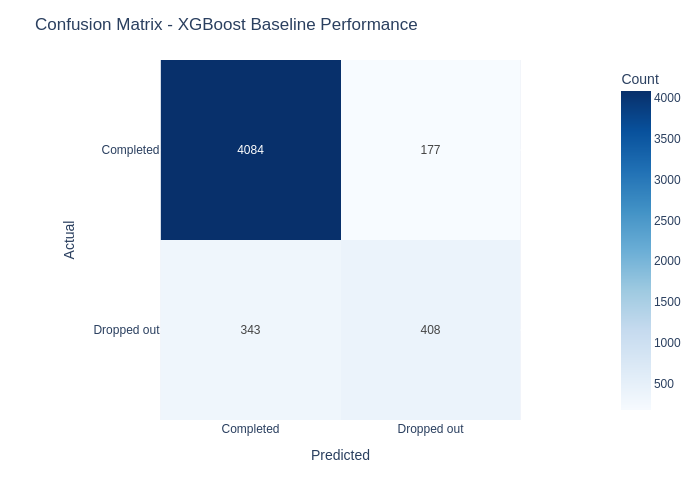

In [ ]:
#Display confusion matrix
labels=['Completed', 'Dropped out']
fig = px.imshow(
    cm_baseline_xgb_1,
    text_auto=True,
    x=labels,
    y=labels,
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    color_continuous_scale='Blues'
)

fig.update_layout(
    title="Confusion Matrix - XGBoost Baseline Performance",
    xaxis_title="Predicted",
    yaxis_title="Actual"
)

fig.write_image("cm_XGBoost_baseline.png")
display(Image("cm_XGBoost_baseline.png"))

Create XGBOOST model through hp tuning

In [ ]:
hp_xgb_1 = hp_xgb(X_train, y_train, X_val, y_val)

In [ ]:
#Evaluate the best hp XGBoost model and compare to baseline
model_performance = []

cm_hp_xgb_1, metrics_hp_xgb_1, PR_hp_xgb_1 = evaluate_model(model = hp_xgb_1, X_test=X_test, y_test=y_test)
model_performance.append(metrics_hp_xgb_1)
ev_hp_xgb_1 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_xgb_1, ev_hp_xgb_1))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.896249,0.858939,-0.03731,0.697436,0.519749,-0.177687,0.543276,0.770972,0.227696,0.610778,0.620912,0.010133,0.663329,0.668084,0.004755


None

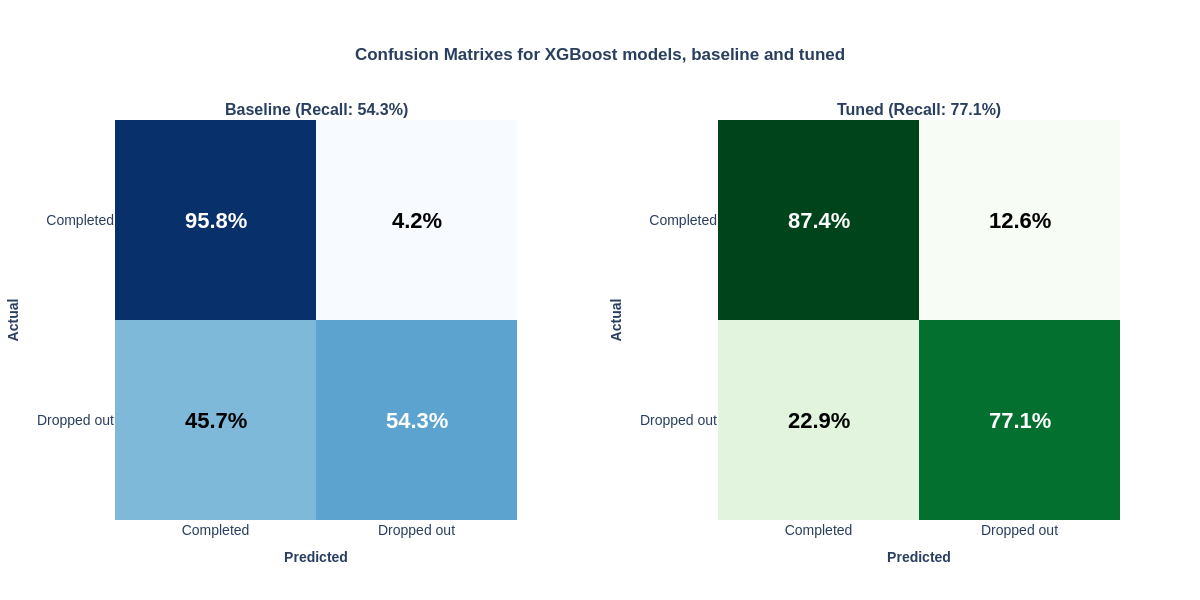

In [ ]:
#Compare CMs
fig = compare_cms(cm_baseline_xgb_1, cm_hp_xgb_1, name_left="Baseline", name_right="Tuned", title = 'Confusion Matrixes for XGBoost models, baseline and tuned')

fig.write_image("cms_XGBoost_bf_aft.png")
display(Image("cms_XGBoost_bf_aft.png"))

Plot feature importance

In [ ]:
shap.initjs()

# SHAP values
shap_ex = shap.TreeExplainer(hp_xgb_1)
vals = shap_ex(X_test)

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



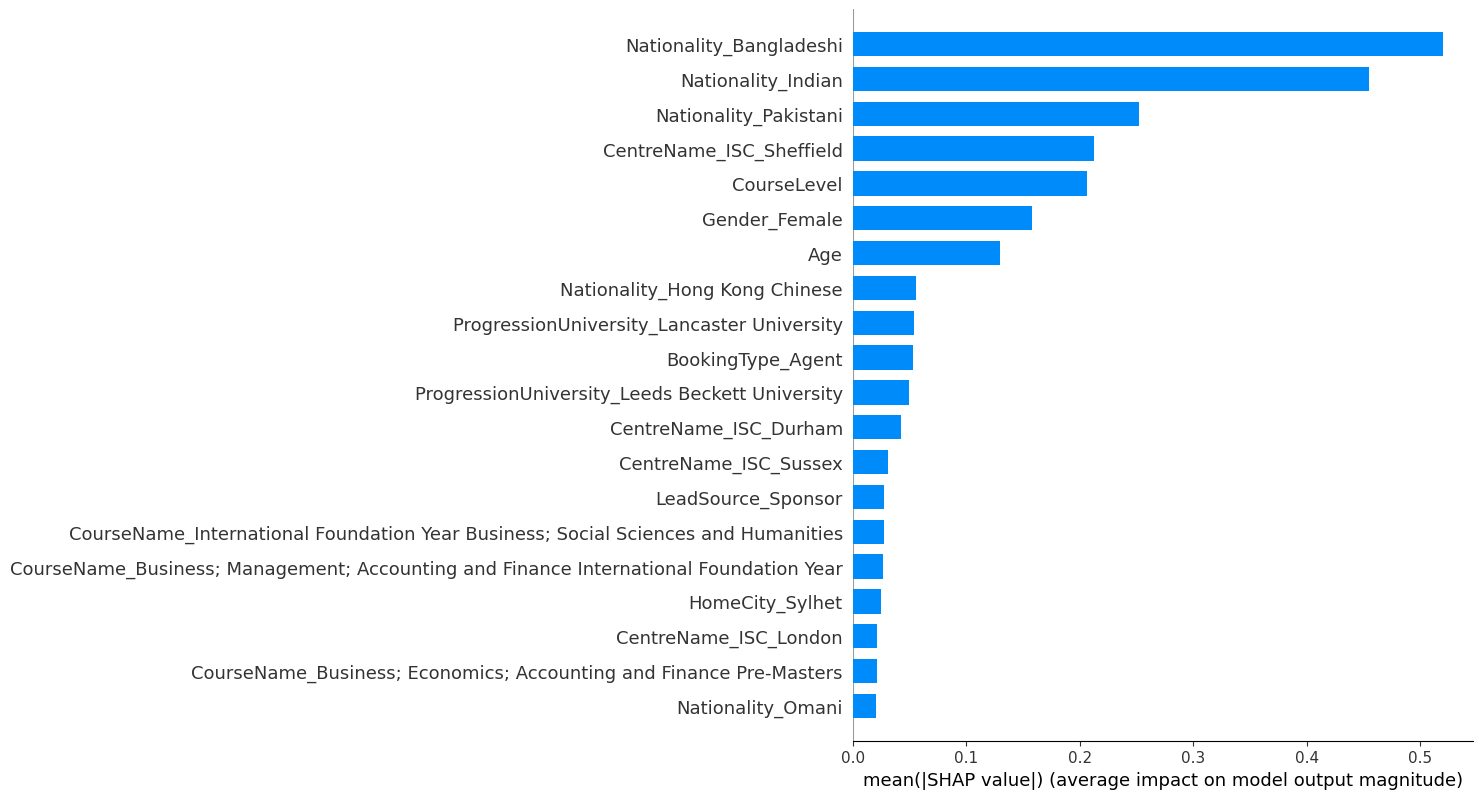

<Figure size 640x480 with 0 Axes>

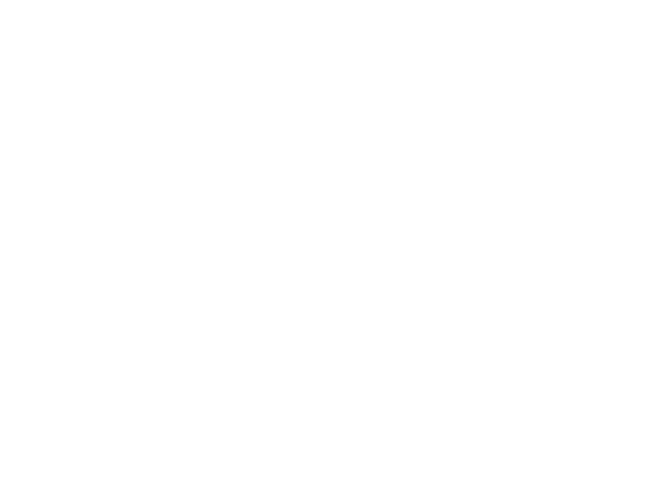

In [ ]:
shap.summary_plot(vals, X_test, plot_type="bar")

plt.savefig("shap_summary1.png", bbox_inches="tight")
plt.show()

display(Image("shap_summary1.png"))

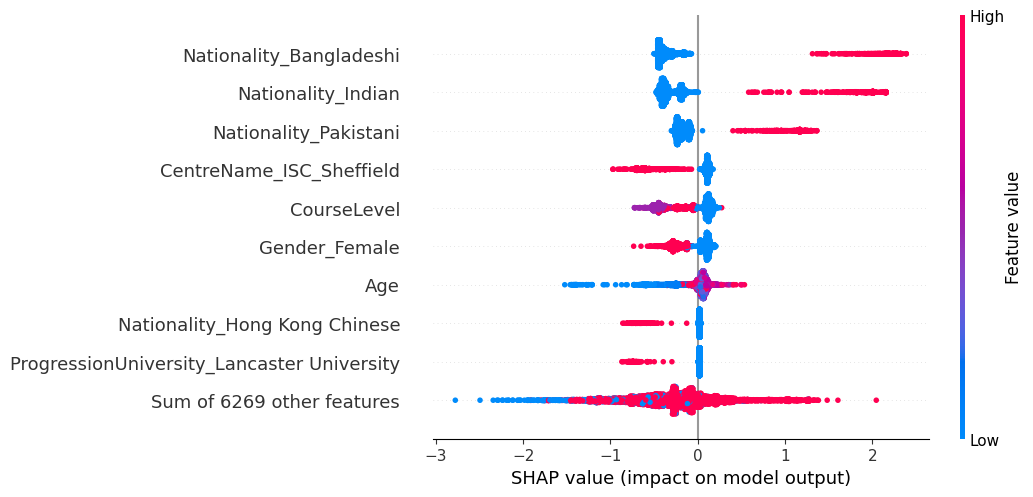

<Figure size 640x480 with 0 Axes>

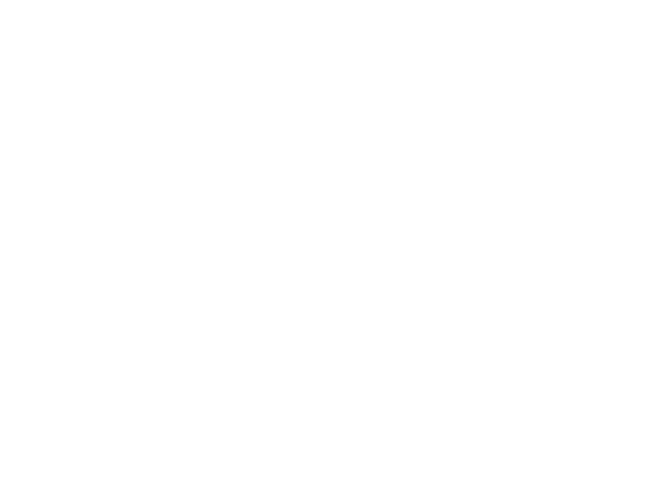

In [ ]:
shap.plots.beeswarm(vals)
plt.savefig("shap_beeswarm1.png", bbox_inches="tight")
plt.show()

display(Image("shap_beeswarm1.png"))

**Observations on feature importance**

How to 'read' this plot:


*   Positive SHAP Values, to the right of 0 on the x-axis: These feature values increase the probability of the target outcome (dropout).
*   Negative SHAP Values (left side of 0): These feature values decrease the probability of dropout (that is, they contribute to student retention).
*   Colour indicates the feature value - for most of them in the plot, the feature is binary (0 or 1) as a result of one-hot encoding. Hence, only two shades: red (1) and blue (0)

What we can see is that demographic factors - such as nationality and gender - are influencing the target variable. In particular:



*   The long red tails to the right for nationality values Bangladeshi, Indian, and Pakistani indicate that students with these nationalities are at higher risk of drop-out
*   Connversely, Hong Kong students are at less risk of drop-out
*   There is a blue tail extending left for age, suggesting that younger students are at less risk of drop out
* For female students, there are red dots slightly to the left of the center line, suggesting that being female has some effect on reducing the likelihood of dropping out.

Alongside that, studying at the Sheffield Centre or Lancester seems to act as a protective factor against student drop-out.

Create neural network model

In [ ]:
epochs = 20
patience = 5
batch_size = 128

In [ ]:
#Create baseline neural network
baseline_neural_1, history_baseline_neural_1 = create_baseline_neural(X_train, y_train, X_val, y_val, epochs = epochs, patience=patience, batch_size=batch_size, model_name='baseline_neural_1')

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.9240 - pr_auc: 0.4865 - val_loss: 0.4790 - val_pr_auc: 0.6274
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7342 - pr_auc: 0.6512 - val_loss: 0.3492 - val_pr_auc: 0.6498
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7156 - pr_auc: 0.6495 - val_loss: 0.3963 - val_pr_auc: 0.6563
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6899 - pr_auc: 0.6843 - val_loss: 0.4974 - val_pr_auc: 0.6531
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6895 - pr_auc: 0.6886 - val_loss: 0.4036 - val_pr_auc: 0.6610
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6759 - pr_auc: 0.7026 - val_loss: 0.4149 - val_pr_auc: 0.6645
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6662 - pr_auc: 0.6959 - val_loss: 0.4016 - val_pr_auc: 0.6648
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6689 - pr_auc: 0.7006 - val_loss: 0.4869 - val_pr_auc: 0.6557
Epoch 9

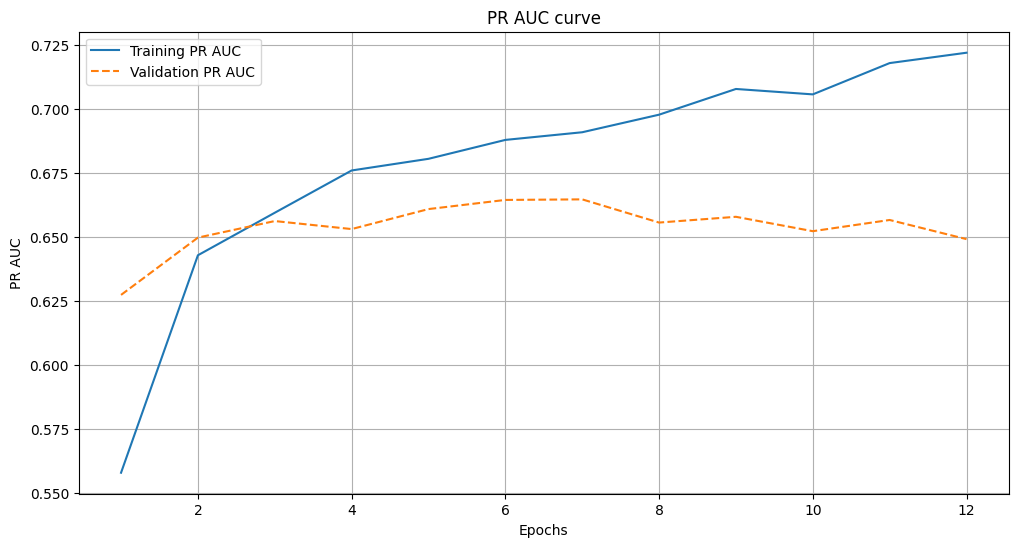

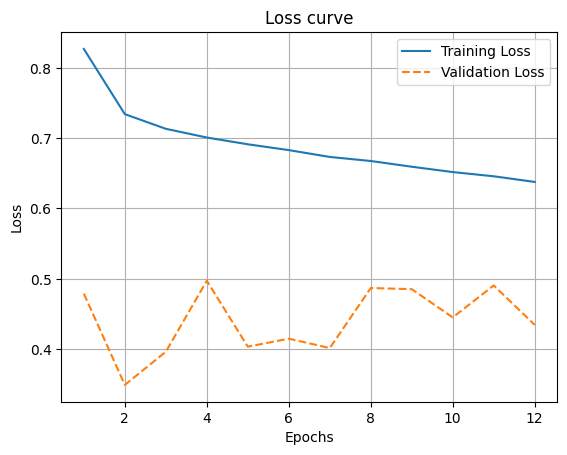

In [ ]:
epochs = len(history_baseline_neural_1.history['pr_auc']) #Handles early stopping
plt = plot_training_history(history_baseline_neural_1, epochs=epochs)

plt.savefig("hist_baseline_neural_1", bbox_inches="tight")
plt.show()


In [ ]:
#Evaluate baseline model & display results
model_performance = []
cm_baseline_neural_1, metrics_baseline_neural_1, PR_baseline_neural_1= evaluate_model(model = baseline_neural_1, X_test=X_test, y_test=y_test)

model_performance.append(metrics_baseline_neural_1)
ev_baseline_neural_1 = pd.DataFrame(model_performance)

display(ev_baseline_neural_1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.861532,0.525745,0.774967,0.62648,0.652741


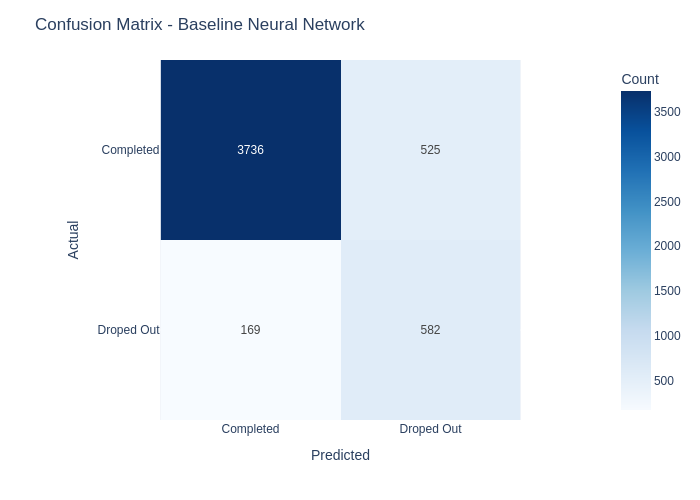

In [ ]:
#Display Confusion Matrix
labels=['Completed', 'Droped Out']
fig = px.imshow(
    cm_baseline_neural_1,
    text_auto=True,
    x=labels,
    y=labels,
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    color_continuous_scale='Blues'
)

fig.update_layout(
    title="Confusion Matrix - Baseline Neural Network",
    xaxis_title="Predicted",
    yaxis_title="Actual"
)

fig.write_image("cm_baseline_neural.png")
display(Image("cm_baseline_neural.png"))

In [ ]:
#HP tune the neural network
hp_neural_1_builder = partial(compile_hp_neural_model, input_dim = X_train.shape[1])
best_hp_neural_1, best_params_hp_neural_1 = hp_neural_search(hp_neural_1_builder, X_train, y_train, X_val, y_val, epochs, batch_size, dir ='student drop out', proj_name = 'Stage1')

Reloading Tuner from student drop out/Stage1/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 



In [ ]:
n_best_units_layer1 = best_params_hp_neural_1.get('units_1')
n_best_units_layer2 = best_params_hp_neural_1.get('units_2')
best_optimizer = best_params_hp_neural_1.get('optimizer')
best_activation_function_layer1 = best_params_hp_neural_1.get('activation_1')
best_activation_function_layer2 = best_params_hp_neural_1.get('activation_2')

print(f"The best number of units for layer 1 is: {n_best_units_layer1}")
print(f"The best number of units for layer 2 is: {n_best_units_layer2}")
print(f"The best optimizer is: {best_optimizer}")
print(f"The best activation function for layer 1 is: {best_activation_function_layer1}")
print(f"The best activation function for layer 2 is: {best_activation_function_layer2}")

The best number of units for layer 1 is: 128
The best number of units for layer 2 is: 192
The best optimizer is: Adam
The best activation function for layer 1 is: relu
The best activation function for layer 2 is: elu


In [ ]:
#Evaluate the model
model_performance = []

cm_hp_neural_1, metrics_hp_neural_1, PR_hp_neural_1 = evaluate_model(model = best_hp_neural_1, X_test=X_test, y_test=y_test)

model_performance.append(metrics_hp_neural_1)
ev_hp_neural_1 = pd.DataFrame(model_performance)

display(ev_hp_neural_1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.855547,0.512,0.766977,0.614072,0.661796


In [ ]:
#Compare the models
compare_performance(ev_baseline_neural_1, ev_hp_neural_1)

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.861532,0.855547,-0.005986,0.525745,0.512,-0.013745,0.774967,0.766977,-0.007989,0.62648,0.614072,-0.012408,0.652741,0.661796,0.009055


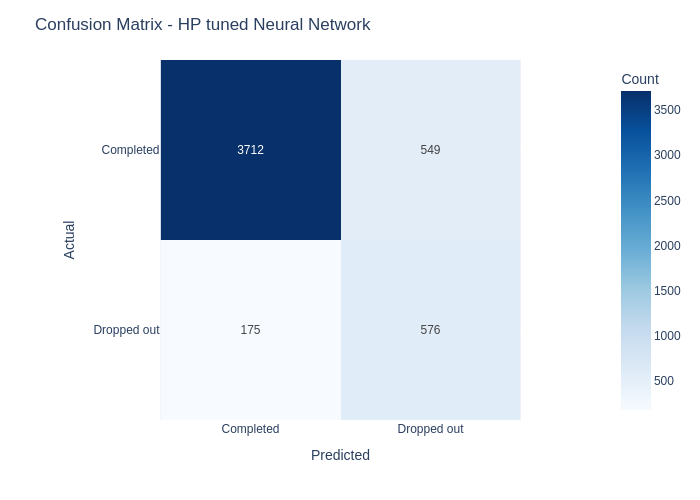

In [ ]:
#Display Confusion Matrix
labels=['Completed', 'Dropped out']
fig = px.imshow(
    cm_hp_neural_1,
    text_auto=True,
    x=labels,
    y=labels,
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    color_continuous_scale='Blues'
)

fig.update_layout(
    title="Confusion Matrix - HP tuned Neural Network",
    xaxis_title="Predicted",
    yaxis_title="Actual"
)

fig.write_image("cm_hp_tuned_neural.png")
display(Image("cm_hp_tuned_neural.png"))

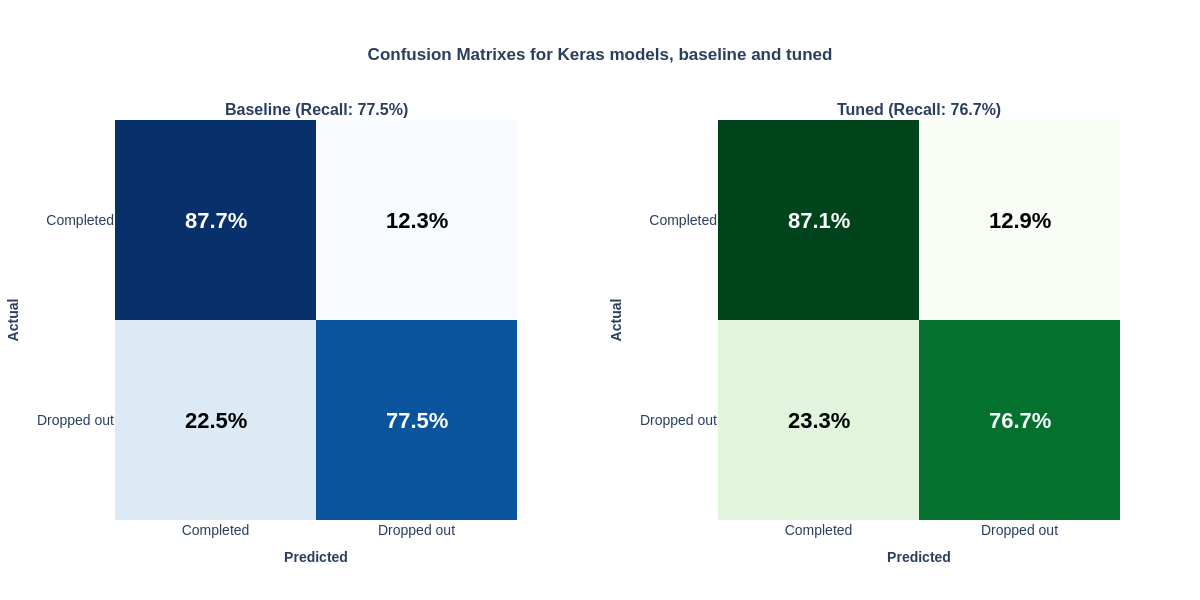

In [ ]:
#Compare the two Confusion Matrixes - Keras before and after hp tuning
fig = compare_cms(cm_baseline_neural_1, cm_hp_neural_1, name_left="Baseline", name_right="Tuned", title = 'Confusion Matrixes for Keras models, baseline and tuned')

fig.write_image("cms_keras_bf_aft.png")
display(Image("cms_keras_bf_aft.png"))

# Stage 2 data

In [ ]:
# File URL
file_url2 = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

In [ ]:
data2 = pd.read_csv(file_url2)

In [ ]:
data2.sample()

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
8144,ISC_LJMU,2438358,Agent,Standard Agent Booking,NaN,25/11/2000,Male,Egyptian,NaN,NaN,Foundation,Business; Law and Social Studies International...,False,Yes,BA (Hons) Sport Business,Liverpool John Moores University,45.0,25.0


In [ ]:
data2.shape

(25059, 18)

**Stage 2: Pre-processing**




In [ ]:
#Convert target variable - CompletedCourse - to a binary value
data2['CompletedCourse'] = np.where(data2['CompletedCourse'].str.lower() == 'yes', 0, 1)

In [ ]:
#Convert 'IsFirstIntake' from Boolean to binary
data2['IsFirstIntake'] = np.where(data2['IsFirstIntake'] == 'yes', 1, 0)

In [ ]:
#Convert date of birth to age
data2['Age'] = (pd.to_datetime('today') - pd.to_datetime(data2['DateofBirth'], dayfirst=True)).dt.days // 365
data2 = data2.drop(columns = ['DateofBirth'])

In [ ]:
#Drop 'LeanerCode'
data2 = data2.drop(columns=['LearnerCode'])

#Remove features withg high cardinality
cat_columns2 = ['CentreName', 'BookingType', 'LeadSource',
       'DiscountType', 'Gender', 'Nationality', 'HomeState',
       'HomeCity', 'CourseLevel', 'CourseName','ProgressionDegree', 'ProgressionUniversity']

data2, cat_columns2 = remove_high_cardinality(benchmark = 200, data = data2, cat_columns = cat_columns2)

#Remove columns with >50% missing data
data2, cat_columns2 = remove_high_NA(benchmark = 0.5, data = data2, cat_columns = cat_columns2)

Dropped: 'HomeState'
Dropped: 'ProgressionDegree'
Dropped: 'DiscountType'


In [ ]:
#Identify ordinal data
print(data2['CourseLevel'].value_counts())


CourseLevel
Foundation                14666
Pre-Masters                5905
International Year One     4441
International Year Two       47
Name: count, dtype: int64


In [ ]:
#Ordinaly encode CourseLevel data
course_order = ['Foundation', 'Pre-Masters', 'International Year One', 'International Year Two']
ordinal_encoder = OrdinalEncoder(categories=[course_order])

data2['CourseLevel'] = ordinal_encoder.fit_transform(data2[['CourseLevel']]).astype(int)

if 'CourseLevel' in cat_columns2:
    cat_columns2.remove('CourseLevel')

In [ ]:
#Identify any missing values

missing_counts = data2.isnull().sum()
features_missing = missing_counts[missing_counts > 0]

missing_summary = pd.DataFrame({
    'missing_count': features_missing,
    'missing_pct': features_missing / len(data2) * 100
})

missing_summary

,missing_count,missing_pct
HomeCity,3448,13.759528
AuthorisedAbsenceCount,208,0.830041
UnauthorisedAbsenceCount,208,0.830041


In [ ]:
#Check if there is evidence that null can be read as 0
n_count0_auth_absence = (data2['AuthorisedAbsenceCount'] == 0).sum()
print(f"There are {n_count0_auth_absence} rows with 0 in the authorised absence column")

n_count0_unauth_absence = (data2['UnauthorisedAbsenceCount'] == 0).sum()
print(f"There are {n_count0_unauth_absence} rows with 0 in the unauthorised absence column")

There are 11203 rows with 0 in the authorised absence column
There are 499 rows with 0 in the unauthorised absence column


In [ ]:
#Impute HomeCity with mode from nationality
data2 = impute_home_city(data2)

In [ ]:
#Remove rows with missing values in the two absence count columns
data2 = data2.dropna(subset=['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount'], how='any')

In [ ]:
#Perform one-hot encoding for all other categorical data.
data2 = pd.get_dummies(data2, columns=cat_columns2, drop_first=False, dtype=int)

In [ ]:
#Create training and validation data
y2 = data2['CompletedCourse']
X2 = data2.drop(columns=['CompletedCourse'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, stratify = y2, random_state = seed)
X_train2, X_val2, y_train2, y_val2 = train_test_split(X_train2, y_train2, test_size = 0.1, stratify = y_train2, random_state=seed)

Create baseline models - for XGBoost

In [ ]:
baseline_xgb_2 = create_baseline_xgb(X_train2, y_train2, X_val2, y_val2)

In [ ]:
#Evaluate performance
model_performance = []

cm_baseline_xgb_2, metrics_baseline_xgb_2, PR_baseline_xgb_2 = evaluate_model(model = baseline_xgb_2, X_test=X_test2, y_test=y_test2)
model_performance.append(metrics_baseline_xgb_2)
ev_baseline_xgb_2 = pd.DataFrame(model_performance)

display(ev_baseline_xgb_2)

,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,XGBClassifier,0.91028,0.744681,0.581717,0.653188,0.732229


In [ ]:
#Create baseline neural model
baseline_neural_2, history_baseline_neural_2 = create_baseline_neural(X_train2, y_train2, X_val2, y_val2, epochs = epochs, patience=patience, batch_size=batch_size, model_name='baseline_neural_2')

Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.8748 - pr_auc: 0.4804 - val_loss: 0.2807 - val_pr_auc: 0.6262
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7017 - pr_auc: 0.6547 - val_loss: 0.4261 - val_pr_auc: 0.6534
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6432 - pr_auc: 0.6842 - val_loss: 0.3481 - val_pr_auc: 0.6735
Epoch 4/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6403 - pr_auc: 0.6967 - val_loss: 0.4397 - val_pr_auc: 0.6701
Epoch 5/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6242 - pr_auc: 0.6932 - val_loss: 0.3556 - val_pr_auc: 0.6762
Epoch 6/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6107 - pr_auc: 0.7192 - val_loss: 0.3914 - val_pr_auc: 0.6670
Epoch 7/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5942 - pr_auc: 0.7224 - val_loss: 0.3584 - val_pr_auc: 0.6992
Epoch 8/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5864 - pr_auc: 0.7251 - val_loss: 0.3668 - val_pr_auc: 0.6831
Epoch 9

In [ ]:
#Evaluate performance
model_performance = []
cm_baseline_neural_2, metrics_baseline_neural_2, PR_baseline_neural_2 = evaluate_model(model = baseline_neural_2, X_test=X_test2, y_test=y_test2)

model_performance.append(metrics_baseline_neural_2)
ev_baseline_neural_2 = pd.DataFrame(model_performance)

display(ev_baseline_neural_2)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.859183,0.509599,0.808864,0.625268,0.720914


In [ ]:
#Compare performance of the baseline models - Stage1 Vs Stage2
#XGBoost
compare_performance(ev_baseline_xgb_1, ev_baseline_xgb_2)

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.896049,0.91028,0.01423,0.692953,0.744681,0.051728,0.549933,0.581717,0.031784,0.613215,0.653188,0.039974,0.664562,0.732229,0.067667


In [ ]:
#Neural network
display(compare_performance(ev_baseline_neural_1, ev_baseline_neural_2))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.861532,0.859183,-0.002349,0.525745,0.509599,-0.016147,0.774967,0.808864,0.033898,0.62648,0.625268,-0.001212,0.652741,0.720914,0.068172


None

**Observations on why the results are different**

Both baseline models (XGBoost and Keras) are performing better on the Stage 2 dataset, with gains, on the PR AUC average score, of 0.07.

At Stage Two, new data has been introduced on students authorised and unauthorised absences. This in effect moves the data from describing who students are, to how they are behaving. Adding in this data has, maybe unsurprisingly, therefore improved the predictive accuracy of the models.

Carry out hyper-parameter tuning

In [ ]:
#XGBoost model
hp_xgb_2 = hp_xgb(X_train2, y_train2, X_val2, y_val2)

In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_xgb_2, metrics_hp_xgb_2, PR_hp_xgb_2 = evaluate_model(model = hp_xgb_2, X_test=X_test2, y_test=y_test2)
model_performance.append(metrics_hp_xgb_2)
ev_hp_xgb_2 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_xgb_2, ev_hp_xgb_2))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.91028,0.873667,-0.036612,0.744681,0.54434,-0.200341,0.581717,0.799169,0.217452,0.653188,0.647587,-0.005601,0.732229,0.719324,-0.012904


None

In [ ]:
#Examine shap values from the XGBoost model on Stage Two data
shap.initjs()

# SHAP values
shap_ex2 = shap.TreeExplainer(hp_xgb_2)
vals2 = shap_ex2(X_test2)

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



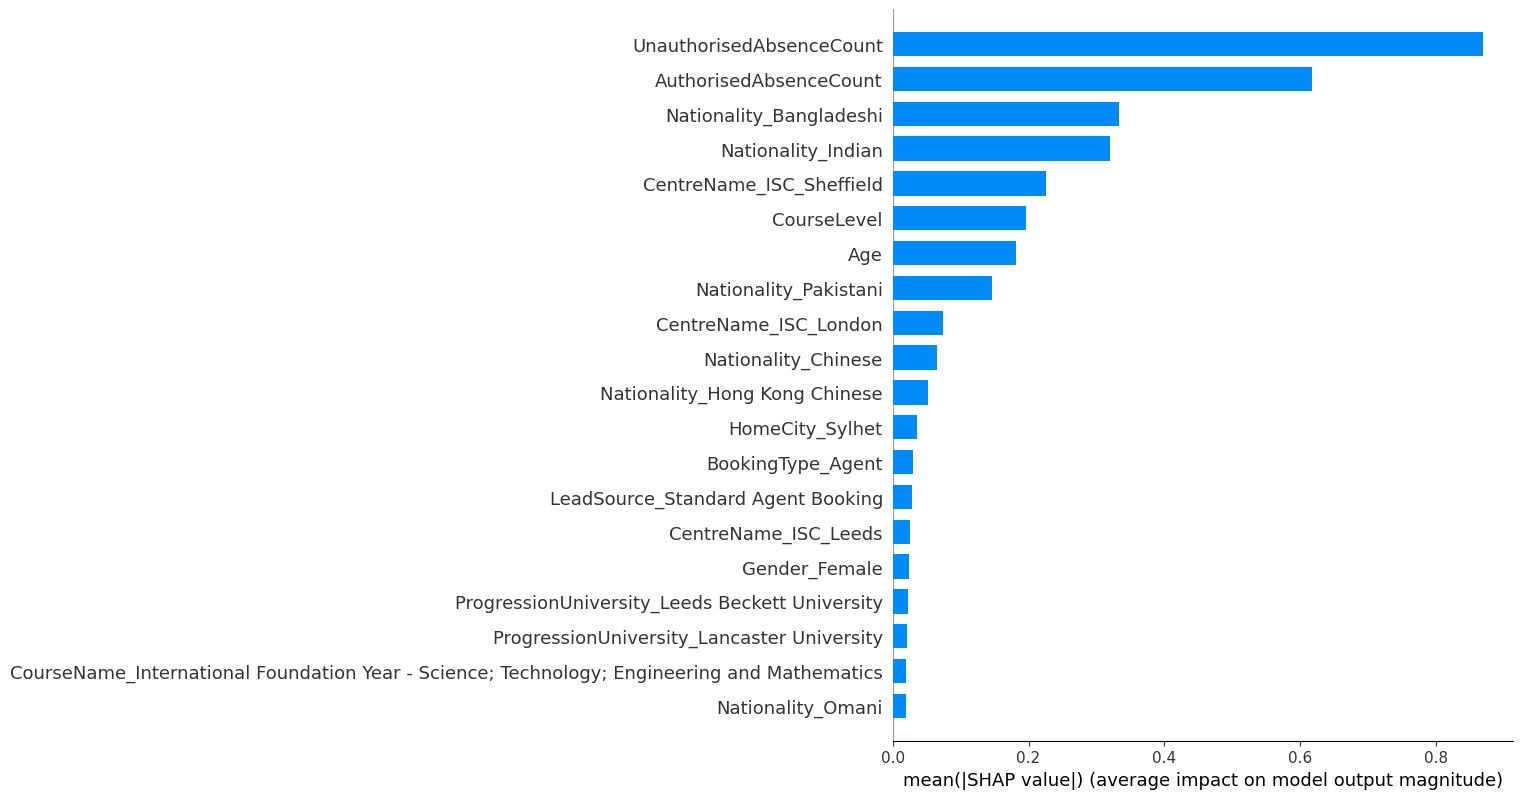

<Figure size 640x480 with 0 Axes>

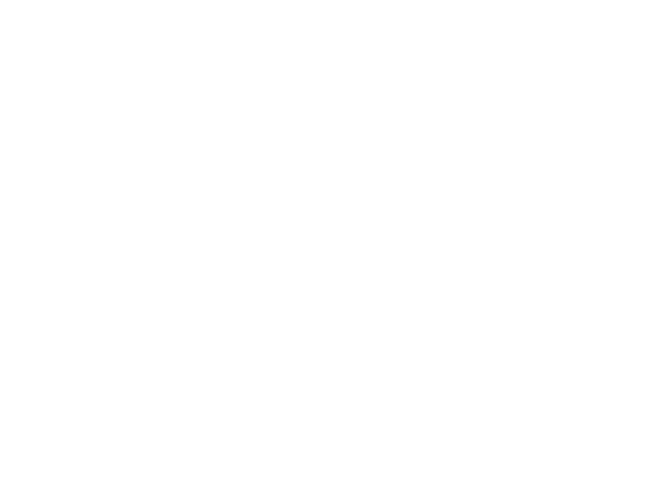

In [ ]:
shap.summary_plot(vals2, X_test2, plot_type="bar")

plt.savefig("summary2.png", bbox_inches="tight")
plt.show()
display(Image("summary2.png"))

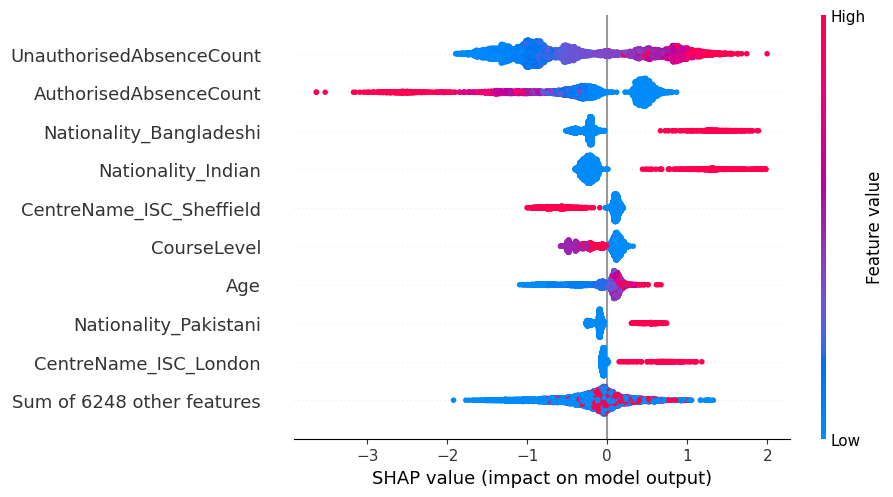

<Figure size 640x480 with 0 Axes>

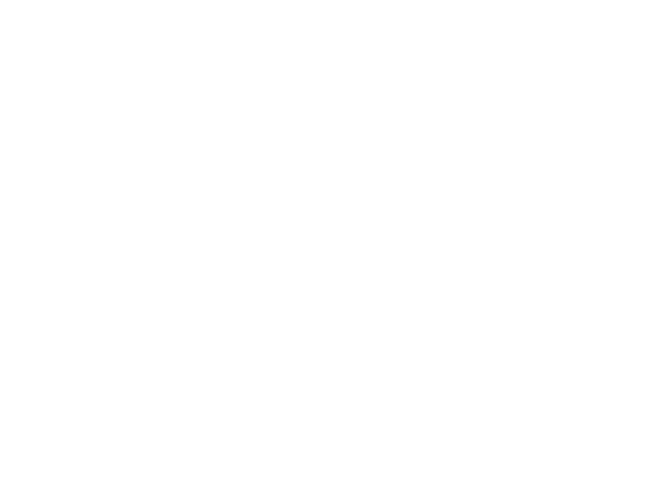

In [ ]:
shap.plots.beeswarm(vals2)
plt.savefig("beeswarm2.png", bbox_inches="tight")
plt.show()

display(Image("beeswarm2.png"))

In [ ]:
#Neural model
hp_neural_2_builder = partial(compile_hp_neural_model, input_dim=X_train2.shape[1])
best_hp_neural_2, best_params_hp_neural_2 = hp_neural_search(hp_neural_2_builder, X_train2, y_train2, X_val2, y_val2, epochs, batch_size, dir ='student drop out', proj_name = 'Stage2')

Trial 30 Complete [00h 00m 18s]
val_pr_auc: 0.6776578426361084

Best val_pr_auc So Far: 0.7108907699584961
Total elapsed time: 00h 06m 31s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning:

Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 



In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_neural_2, metrics_hp_neural_2, PR_hp_neural_2 = evaluate_model(model = best_hp_neural_2, X_test=X_test2, y_test=y_test2)

model_performance.append(metrics_hp_neural_2)
ev_hp_neural_2 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_neural_2, ev_hp_neural_2))

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.859183,0.768256,-0.090927,0.509599,0.37529,-0.134309,0.808864,0.896122,0.087258,0.625268,0.529027,-0.096241,0.720914,0.718792,-0.002122


None

**Commment on performance improvement**

On the Stage Two datset, both hp tuned XGBoost model and the hp tuned Keras model, judged on the PR AUC metric, perform less well - but by a very small amount. This contrasts with the gains in performance that we saw through adding in new data (the comparison between Stage One performance and Stage Two.)

Looking at the shap plots for the XGBoost model, the two most important predictive features are now unauthorised and authorised absence. On the former, the relationship between it and dropout looks very linear - the higher the number of unauthorised drop-outs, the greater the risk.

It is likely that both models find this "rule" instantly with their default settings. Hence, hp tuning is not improving performance.

This suggests that effort is better spent on sourcing additional behavioural data, than performance tuning of existing parameters.

# Stage 3 data

In [ ]:
# File URL
file_url3 = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

**Stage 3: Pre-processing**






In [ ]:
data3 = pd.read_csv(file_url3)

In [ ]:
data3.shape

(25059, 21)

In [ ]:
data3.sample(5)

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
768,ISC_Cardiff,2614202,Direct,Referrals,NaN,14/07/2004,Female,Chinese,NaN,NaN,...,International Year One - Accounting and Finance,True,Yes,10.0,10.0,0.0,Mathematics Operational Research & Stats,Cardiff University,12.0,46.0
4514,ISC_Huddersfield,2487373,Agent,Standard Agent Booking,NaN,6/7/1999,Male,Bangladeshi,NaN,NaN,...,International Foundation Year Business; Manage...,True,Yes,6.0,3.0,3.0,BA (Hons) Business Management and Leadership,University of Huddersfield,21.0,74.0
19246,ISC_Sheffield,2662417,Agent,Standard Agent Booking,NaN,18/04/1999,Male,Chinese,NaN,Huzhou City,...,Pre-Masters Business; Social Sciences and Huma...,False,Yes,4.0,4.0,0.0,MSc Human Resource Management with CIPD Pathway,University of Sheffield International College,0.0,4.0
4829,ISC_Huddersfield,2554612,Agent,Standard Agent Booking,NaN,10/2/1998,Male,Nepalese,NaN,Chitwan,...,International Foundation Year Health and Human...,False,Yes,6.0,4.0,2.0,BSc (Hons) Health and Social Care,University of Huddersfield,51.0,32.0
3541,ISC_Durham,2671619,Agent,Standard Agent Booking,NaN,7/11/2004,Male,Hong Kong Chinese,NaN,Ma On Shan,...,Science and Engineering International Foundati...,False,Yes,6.0,6.0,0.0,BEng (Hons) Engineering (Mechanical),Durham University,5.0,21.0


In [ ]:
#Convert target variable - CompletedCourse - to a binary value
data3['CompletedCourse'] = np.where(data3['CompletedCourse'].str.lower() == 'yes', 0, 1)

In [ ]:
#Convert 'IsFirstIntake' from Boolean to binary
data3['IsFirstIntake'] = np.where(data3['IsFirstIntake'] == 'yes', 1, 0)

In [ ]:
#Convert date of birth to age
data3['Age'] = (pd.to_datetime('today') - pd.to_datetime(data3['DateofBirth'], dayfirst=True)).dt.days // 365
data3 = data3.drop(columns = ['DateofBirth'])

In [ ]:
#Examine columns
data3.columns

Index(['CentreName', 'LearnerCode', 'BookingType', 'LeadSource',
       'DiscountType', 'Gender', 'Nationality', 'HomeState', 'HomeCity',
       'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse',
       'AssessedModules', 'PassedModules', 'FailedModules',
       'ProgressionDegree', 'ProgressionUniversity', 'AuthorisedAbsenceCount',
       'UnauthorisedAbsenceCount', 'Age'],
      dtype='object')

In [ ]:
#Remove Learner Code
data3 = data3.drop(columns=['LearnerCode'])

#Remove features withg high cardinality
cat_columns3 = ['CentreName', 'BookingType', 'LeadSource',
       'DiscountType', 'Gender', 'Nationality', 'HomeState',
       'HomeCity', 'CourseLevel', 'CourseName','ProgressionDegree', 'ProgressionUniversity']

data3, cat_columns3 = remove_high_cardinality(benchmark = 200, data = data3, cat_columns = cat_columns3)

#Remove columns with >50% missing data
data3, cat_columns3 = remove_high_NA(benchmark = 0.5, data = data3, cat_columns = cat_columns3)

Dropped: 'HomeState'
Dropped: 'ProgressionDegree'
Dropped: 'DiscountType'


In [ ]:
#Examine CourseLevel data
data3['CourseLevel'].value_counts()

,count
CourseLevel,
Foundation,14666
Pre-Masters,5905
International Year One,4441
International Year Two,47


In [ ]:
#Ordinaly encode CourseLevel data
course_order = ['Foundation', 'Pre-Masters', 'International Year One', 'International Year Two']
ordinal_encoder = OrdinalEncoder(categories=[course_order])

data3['CourseLevel'] = ordinal_encoder.fit_transform(data3[['CourseLevel']]).astype(int)

if 'CourseLevel' in cat_columns3:
    cat_columns3.remove('CourseLevel')

In [ ]:
#Identify any missing values
missing_counts = data3.isnull().sum()
features_missing = missing_counts[missing_counts > 0]

missing_summary = pd.DataFrame({
    'missing_count': features_missing,
    'missing_pct': features_missing / len(data3) * 100
})

display(missing_summary)


,missing_count,missing_pct
HomeCity,3448,13.759528
AssessedModules,2231,8.902989
PassedModules,2231,8.902989
FailedModules,2231,8.902989
AuthorisedAbsenceCount,208,0.830041
UnauthorisedAbsenceCount,208,0.830041


In [ ]:
#Check if missing values in the Modules columns are signifiers of drop-out
print(data3[data3['AssessedModules'].isna()]['CompletedCourse'].value_counts(normalize=True))
print(data3[data3['PassedModules'].isna()]['CompletedCourse'].value_counts(normalize=True))
print(data3[data3['FailedModules'].isna()]['CompletedCourse'].value_counts(normalize=True))

#All people with missing values are drop outs

CompletedCourse
1    1.0
Name: proportion, dtype: float64
CompletedCourse
1    1.0
Name: proportion, dtype: float64
CompletedCourse
1    1.0
Name: proportion, dtype: float64


In [ ]:
#Create the indicator to indicate missing Module data
data3['Modules_Missing_Flag'] = data3['AssessedModules'].isna().astype(int)

#Fill the actual NAs with a constant, -1
data3[['AssessedModules', 'PassedModules', 'FailedModules']] = data3[['AssessedModules', 'PassedModules', 'FailedModules']].fillna(-1)

In [ ]:
#Impute HomeCity based on mode value from the Nationality column
data3 = impute_home_city(data3)

In [ ]:
#Remove rows with missing values in the two absence count columns
data3 = data3.dropna(subset=['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount'], how='any')

In [ ]:
#Perform one-hot encoding for all other categorical data.
data3 = pd.get_dummies(data3, columns=cat_columns3, drop_first=False, dtype=int)

In [ ]:
#Create training and validation data
y3 = data3['CompletedCourse']
X3 = data3.drop(columns=['CompletedCourse'])

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size = 0.2, stratify = y3, random_state = 67)
X_train3, X_val3, y_train3, y_val3 = train_test_split(X_train3, y_train3, test_size = 0.1, stratify = y_train3,random_state=seed)

In [ ]:
#Create a baseline XGBoost model on the Stage 3 dataset
baseline_xgb_3 = create_baseline_xgb(X_train3, y_train3, X_val3, y_val3)

In [ ]:
#Evaluate performance
model_performance = []

cm_baseline_xgb_3, metrics_baseline_xgb_3, PR_baseline_xgb_3 = evaluate_model(model = baseline_xgb_3, X_test=X_test3, y_test=y_test3)
model_performance.append(metrics_baseline_xgb_3)
ev_baseline_xgb_3 = pd.DataFrame(model_performance)

display(ev_baseline_xgb_3)


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,XGBClassifier,0.99135,0.98293,0.957064,0.969825,0.996454


In [ ]:
#Create baseline neural network
baseline_neural_3, history_baseline_neural_3 = create_baseline_neural(X_train3, y_train3, X_val3, y_val3, epochs = epochs, patience=patience, batch_size=batch_size, model_name='baseline_neural_3')

Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.4055 - pr_auc: 0.8232 - val_loss: 0.0643 - val_pr_auc: 0.9748
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1529 - pr_auc: 0.9709 - val_loss: 0.0883 - val_pr_auc: 0.9783
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1254 - pr_auc: 0.9752 - val_loss: 0.0763 - val_pr_auc: 0.9809
Epoch 4/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1074 - pr_auc: 0.9843 - val_loss: 0.0622 - val_pr_auc: 0.9783
Epoch 5/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0966 - pr_auc: 0.9829 - val_loss: 0.0676 - val_pr_auc: 0.9825
Epoch 6/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0938 - pr_auc: 0.9874 - val_loss: 0.0711 - val_pr_auc: 0.9709
Epoch 7/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0838 - pr_auc: 0.9881 - val_loss: 0.0639 - val_pr_auc: 0.9789
Epoch 8/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0823 - pr_auc: 0.9878 - val_loss: 0.0852 - val_pr_auc: 0.9680
Epoch 9

In [ ]:
#Evaluate Performance
model_performance = []
cm_baseline_neural_3, metrics_baseline_neural_3, PR_baseline_neural_3 = evaluate_model(model = baseline_neural_3, X_test=X_test3, y_test=y_test3)

model_performance.append(metrics_baseline_neural_3)
ev_baseline_neural_3 = pd.DataFrame(model_performance)

display(ev_baseline_neural_3)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Model,Accuracy,Precision,Recall,F1 Score,PR AUC
0,Keras_Neural_Net,0.977872,0.8825,0.977839,0.927727,0.990278


In [ ]:
#Get shap values
shap.initjs()

# SHAP values
shap_ex3 = shap.TreeExplainer(baseline_xgb_3)
vals3 = shap_ex3(X_test3)

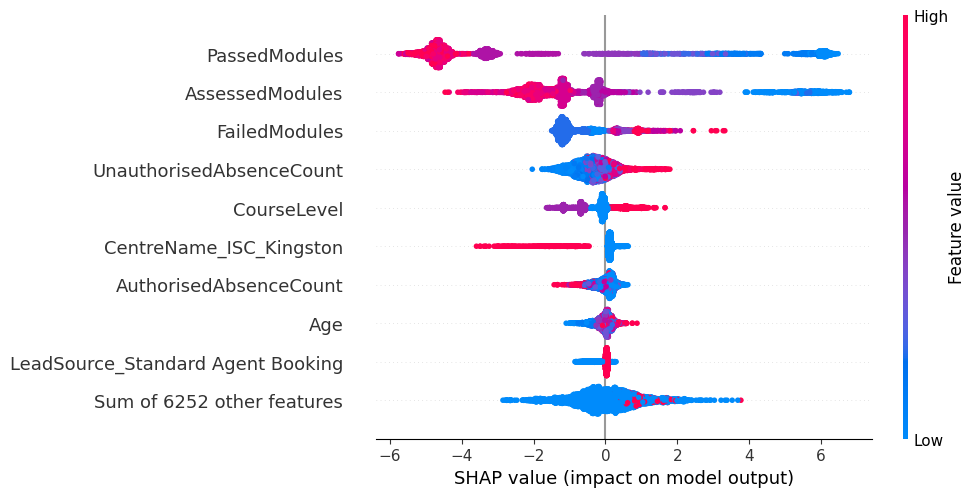

<Figure size 640x480 with 0 Axes>

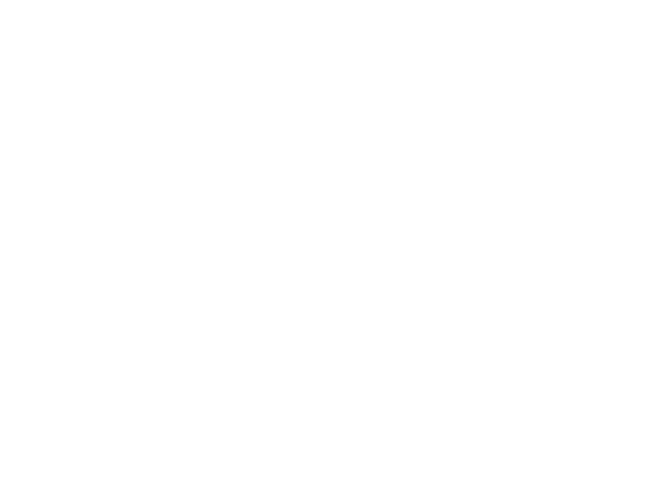

In [ ]:
shap.plots.beeswarm(vals3)
plt.savefig("beeswarm3.png", bbox_inches="tight")
plt.show()

display(Image("beeswarm3.png"))

In [ ]:
#Compare performance of the baseline models - Stage2 Vs Stage3
#XGBoost
display(compare_performance(ev_baseline_xgb_2, ev_baseline_xgb_3))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.91028,0.99135,0.08107,0.744681,0.98293,0.238249,0.581717,0.957064,0.375346,0.653188,0.969825,0.316636,0.732229,0.996454,0.264225


None

In [ ]:
#Neural network
display(compare_performance(ev_baseline_neural_2, ev_baseline_neural_3))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.859183,0.977872,0.118688,0.509599,0.8825,0.372901,0.808864,0.977839,0.168975,0.625268,0.927727,0.302459,0.720914,0.990278,0.269365


None

**Observations on the difference in performance between Stage 2 and Stage 3**

On the stage 3 dataset, both baseline models are performing significantly better on the PR AUC metric, with values approaching 1 - that is, approaching perfect prediction.

This suggests that the data added in at stage three are not signals, but surrogates / proxies for the outcome itself. This is very plausible given what they describe: Number of modules assessed, Number of modules passed, and Number of modules failed.

For example, if a student has 0 modules passed, then it is likely that they will be a drop-out.

This is confirmed by the shap values shown above - the new features at stage three dominate the predictions. The models, at this stage, are not predictive but descriptive.

We should expect very little, if any, improvement from hp tuning ...

Carry out hp tuning

In [ ]:
#XGBoost model
hp_xgb_3 = hp_xgb(X_train3, y_train3, X_val3, y_val3)

In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_xgb_3, metrics_hp_xgb_3, PR_hp_xgb_3 = evaluate_model(model = hp_xgb_3, X_test=X_test3, y_test=y_test3)
model_performance.append(metrics_hp_xgb_3)
ev_hp_xgb_3 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_xgb_3, ev_hp_xgb_3))

,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
XGBClassifier,0.99135,0.984108,-0.007242,0.98293,0.912709,-0.070222,0.957064,0.984765,0.027701,0.969825,0.947368,-0.022456,0.996454,0.994736,-0.001718


None

In [ ]:
#Neural model
hp_neural_3_builder = partial(compile_hp_neural_model, input_dim=X_train3.shape[1])
best_hp_neural_3, best_params_hp_neural_3 = hp_neural_search(hp_neural_3_builder, X_train3, y_train3, X_val3, y_val3, epochs, batch_size, dir ='student drop out', proj_name = 'Stage3')

Trial 30 Complete [00h 00m 20s]
val_pr_auc: 0.9837011694908142

Best val_pr_auc So Far: 0.9840164184570312
Total elapsed time: 00h 06m 44s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning:

Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 



In [ ]:
#Evaluate the model & compare performance before and after tuning
model_performance = []

cm_hp_neural_3, metrics_hp_neural_3, PR_hp_neural_3 = evaluate_model(model = best_hp_neural_3, X_test=X_test3, y_test=y_test3)

model_performance.append(metrics_hp_neural_3)
ev_hp_neural_3 = pd.DataFrame(model_performance)

display(compare_performance(ev_baseline_neural_3, ev_hp_neural_3))

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy_Before,Accuracy_After,Accuracy_Lift,Precision_Before,Precision_After,Precision_Lift,Recall_Before,Recall_After,Recall_Lift,F1 Score_Before,F1 Score_After,F1_Lift,PR AUC_Before,PR AUC_After,PR AUC_Lift
Model,,,,,,,,,,,,,,,
Keras_Neural_Net,0.977872,0.980487,0.002615,0.8825,0.900128,0.017628,0.977839,0.973684,-0.004155,0.927727,0.935462,0.007736,0.990278,0.990569,0.000291


None

**Observations on improvements**
As expected, the performance of both models is not signifcantly affected by hyper-parameter tuning.

This is designed to find subtle, patterns in "noisy" data. At stage three, our dataset is very loud (and clear) meaning that tuning essentially loses its purpose.

# Supplementary Analysis for the report

Plot PR Areas Under the Curve

In [ ]:
#Mapping for Baseline Models
baseline_data = {
    "Stage 1": {"XGBoost": PR_baseline_xgb_1, "Keras": PR_baseline_neural_1},
    "Stage 2": {"XGBoost": PR_baseline_xgb_2, "Keras": PR_baseline_neural_2},
    "Stage 3": {"XGBoost": PR_baseline_xgb_3, "Keras": PR_baseline_neural_3}
}

#Mapping for Tuned Models
tuned_data = {
    "Stage 1": {"XGBoost": PR_hp_xgb_1, "Keras": PR_hp_neural_1},
    "Stage 2": {"XGBoost": PR_hp_xgb_2, "Keras": PR_hp_neural_2},
    "Stage 3": {"XGBoost": PR_hp_xgb_3, "Keras": PR_hp_neural_3}
}

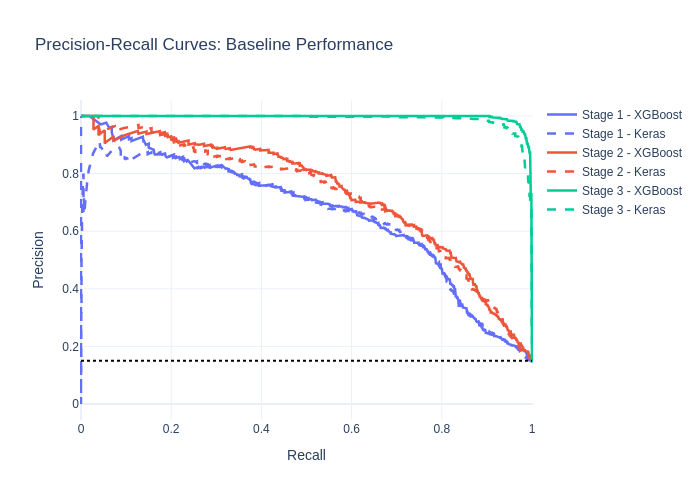

In [ ]:
#Plot baseline models results
fig_baseline = go.Figure()

stage_colors = {"Stage 1": "#636EFA", "Stage 2": "#EF553B", "Stage 3": "#00CC96"}
model_styles = {"XGBoost": "solid", "Keras": "dash"}

for stage, models in baseline_data.items():
    for model_type, pr_tuple in models.items():
        fig_baseline.add_trace(go.Scatter(
            x=pr_tuple[1], # Recalls
            y=pr_tuple[0], # Precisions
            name=f"{stage} - {model_type}",
            mode='lines',
            line=dict(color=stage_colors[stage], dash=model_styles[model_type], width=2.5)
        ))

#Add the 15% drop-out baseline
fig_baseline.add_shape(type="line", x0=0, x1=1, y0=0.15, y1=0.15, line=dict(color="black", dash="dot"))

fig_baseline.update_layout(
    title="Precision-Recall Curves: Baseline Performance",
    xaxis_title="Recall", yaxis_title="Precision",
    template="plotly_white"
)

fig_baseline.write_image("baseline_pr_curves.png")
display(Image("baseline_pr_curves.png"))

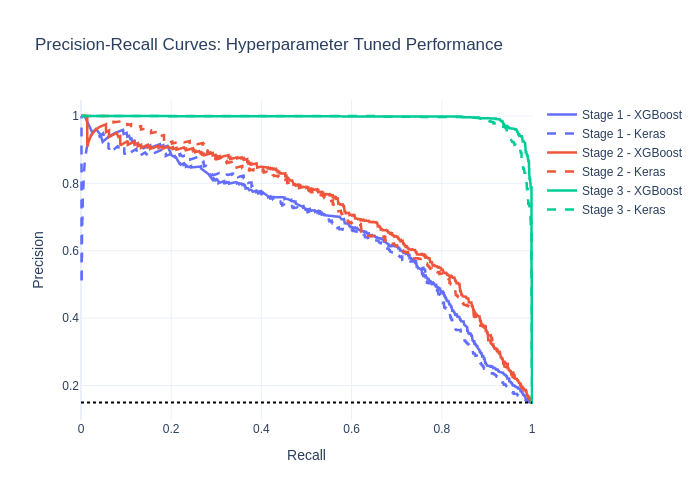

In [ ]:
#Plot HP tuned model results
fig_tuned = go.Figure()

for stage, models in tuned_data.items():
    for model_type, pr_tuple in models.items():
        fig_tuned.add_trace(go.Scatter(
            x=pr_tuple[1], # Recalls
            y=pr_tuple[0], # Precisions
            name=f"{stage} - {model_type}",
            mode='lines',
            line=dict(color=stage_colors[stage], dash=model_styles[model_type], width=2.5)
        ))

# Add the 15% drop-out baseline
fig_tuned.add_shape(type="line", x0=0, x1=1, y0=0.15, y1=0.15, line=dict(color="black", dash="dot"))

fig_tuned.update_layout(
    title="Precision-Recall Curves: Hyperparameter Tuned Performance",
    xaxis_title="Recall", yaxis_title="Precision",
    template="plotly_white"
)


fig_tuned.write_image("tuned_pr_curves.png")
display(Image("tuned_pr_curves.png"))

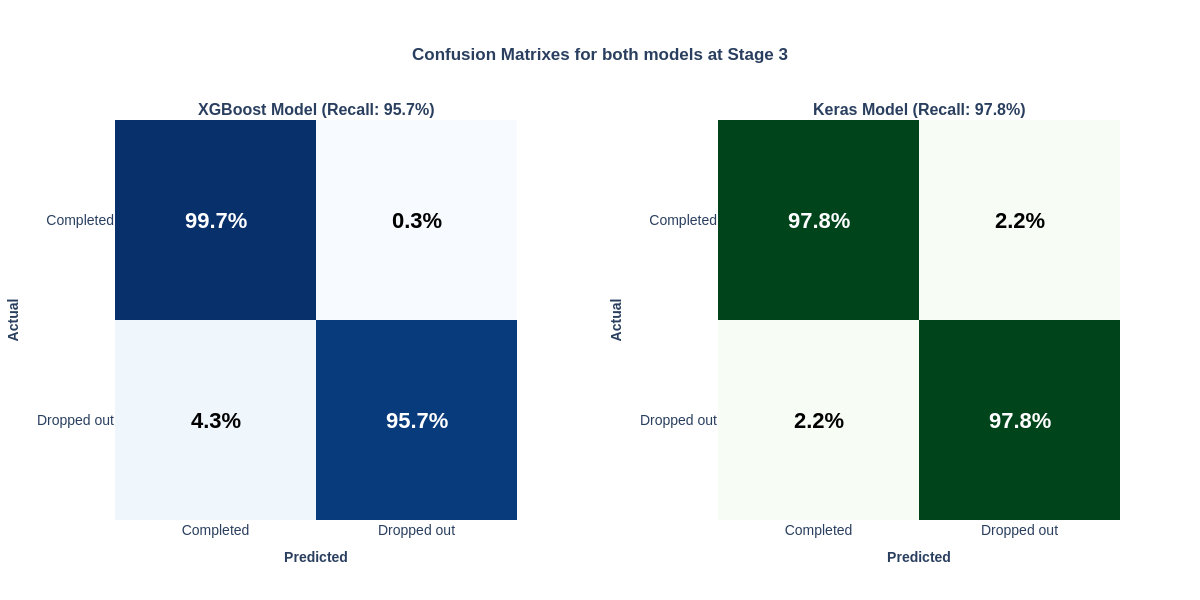

In [ ]:
#CM Matrixes at Stage Three
fig = compare_cms(cm_baseline_xgb_3, cm_baseline_neural_3, name_left="XGBoost Model", name_right="Keras Model", title = 'Confusion Matrixes for both models at Stage 3')
fig.write_image("cms_stage3.png")
display(Image("cms_stage3.png"))

# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
